PROGETTO 3

Implementare e confrontare due diversi algoritmi di classificazione, K-Nearest Neighbors (KNN) e Support Vector Machine (SVM), dopo aver ridotto la dimensionalità del dataset Wine utilizzando PCA

1. DATA EXPLORATION & PREPROCESSING
- Caricamento e Analisi del dataset e fornire un'analisi descrittiva iniziale (es. df.describe(), df.dtypes)
- Standarization delle feature (X) per garantire che tutti gli attributi abbiano media zero e deviazione standard unitaria.

2. DATA DIMENSIONALITY REDUCTION
- Applicare la PCA (Principal Component Analisys) sui dati standarizzati
- Ridurre la dimensionalità a 2 componenti principali (n_components=2) per facilitare la visualizzazione

3. ADDESTRAMENTO & VALUTAZIONE
- Inizializzare ue modelli_
    1) K-Neares Neighbors (KNN) con n_neighbors=5
    2) Support Vector Machine (SVM) con kernel='linear'
- Addestrare entrambi i modelli utilizzando il dataset ridotto a 2 componenti
- Calcolare e stampare Accuracy Score di entrambi i modelli sull'intero set di dati ridotto

4. ANALISI & VISUALIZZAZIONE
- Generare un grafico con due subplot per confrontare i risultati visivi
- Plottare i dati points colorati in base alla loro classe di appartenenza (target)
- Visualizzare i decision boundary dei modelli (KNN e SVM)

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_squared_error, r2_score

1. DATA EXPLORATION & PREPROCESSING
- Caricamento e Analisi del dataset e fornire un'analisi descrittiva iniziale (es. df.describe(), df.dtypes)
- Standarization delle feature (X) per garantire che tutti gli attributi abbiano media zero e deviazione standard unitaria.


In [19]:
data=load_wine()
X=data.data
y=data.target
display(pd.DataFrame(X, columns=data.feature_names).head())
display(pd.DataFrame(y, columns=["target"]).groupby("target").size())
display(pd.DataFrame(X, columns=data.feature_names).describe())
display(pd.DataFrame(X, columns=data.feature_names).info())

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


target
0    59
1    71
2    48
dtype: int64

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
dtypes: fl

None

2. DATA DIMENSIONALITY REDUCTION
- Applicare la PCA (Principal Component Analisys) sui dati standarizzati
- Ridurre la dimensionalità a 2 componenti principali (n_components=2) per facilitare la visualizzazione

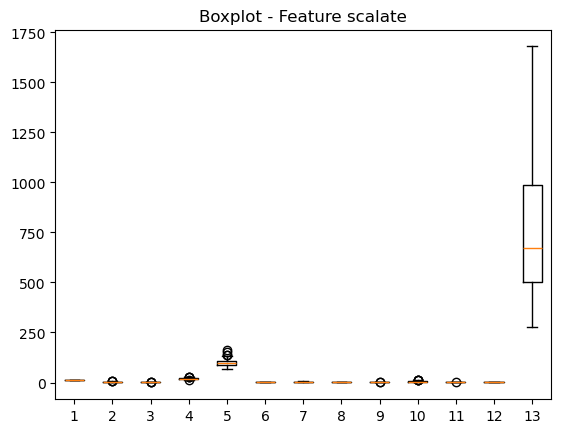

In [20]:
plt.boxplot(X)  #crea un boxplot per ogni feature
#plt.xticks(range(1,len(X.columns)+1), X.columns,rotation=90)
plt.title("Boxplot - Feature scalate")
plt.show()

Standarizzo

In [21]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

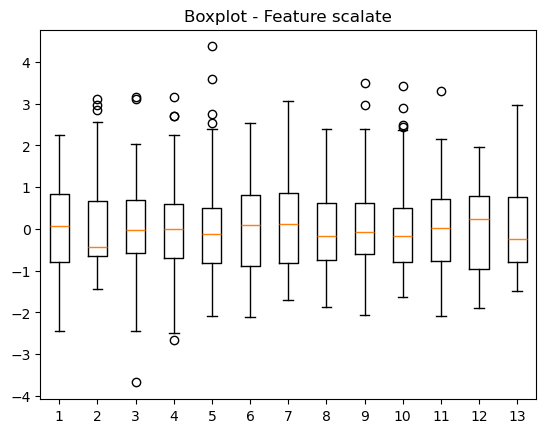

In [22]:
plt.boxplot(X_scaled)  #crea un boxplot per ogni feature
#plt.xticks(range(1,len(X.columns)+1), X.columns,rotation=90)
plt.title("Boxplot - Feature scalate")
plt.show()

In [24]:
pca = PCA(n_components=2)   #tengo solo 2 feature
X_pca = pca.fit_transform(X_scaled)
print(X_pca.shape)  #verifico che abbia solo 2 feature


(178, 2)


3. ADDESTRAMENTO & VALUTAZIONE
- Inizializzare due modelli
    1) K-Neares Neighbors (KNN) con n_neighbors=5
    2) Support Vector Machine (SVM) con kernel='linear'
- Addestrare entrambi i modelli utilizzando il dataset ridotto a 2 componenti
- Calcolare e stampare Accuracy Score di entrambi i modelli sull'intero set di dati ridotto

In [33]:
tot_samples = len(y)

In [34]:
k=5

knn=KNeighborsClassifier(n_neighbors=k)
knn.fit(X_pca,y)
y_pred_knn=knn.predict(X_pca)

mse_knn=mean_squared_error(y,y_pred_knn)
r2_knn=r2_score(y,y_pred_knn)
print(f"KNN \nMSE: {mse_knn}\t R2:{r2_knn}")

correct_arr = (y_pred_knn == y)
correct_count = np.sum(correct_arr)
incorrect_count = tot_samples - correct_count
print(f"TOT:\t{tot_samples}")
print(f"Corretti:\t{correct_count}")
print(f"Incorretti:\t{incorrect_count}")

accuracy = correct_count /tot_samples
print(f"ACCURACY:\t{accuracy * 100:.2f}%")


KNN 
MSE: 0.033707865168539325	 R2:0.9435667107001321
TOT:	178
Corretti:	172
Incorretti:	6
ACCURACY:	96.63%


In [35]:
svc_linear=SVC(kernel="linear",C=1.0,random_state=42)
svc_linear.fit(X_pca,y)
y_pred_linear=svc_linear.predict(X_pca)

mse_linear=mean_squared_error(y,y_pred_linear)
r2_linear=r2_score(y,y_pred_linear)
print(f"LINEAR \nMSE: {mse_linear}\t R2:{r2_linear}")

correct_arr = (y_pred_linear == y)
correct_count = np.sum(correct_arr)
incorrect_count = tot_samples - correct_count
print(f"TOT:\t{tot_samples}")
print(f"Corretti:\t{correct_count}")
print(f"Incorretti:\t{incorrect_count}")

accuracy = correct_count /tot_samples
print(f"ACCURACY:\t{accuracy * 100:.2f}%")

LINEAR 
MSE: 0.028089887640449437	 R2:0.9529722589167767
TOT:	178
Corretti:	173
Incorretti:	5
ACCURACY:	97.19%


4. ANALISI & VISUALIZZAZIONE
- Generare un grafico con due subplot per confrontare i risultati visivi
- Plottare i dati points colorati in base alla loro classe di appartenenza (target)
- Visualizzare i decision boundary dei modelli (KNN e SVM)

In [36]:
X_min, X_max = X_pca[:, 0].min() - 0.5, X_pca[:, 0].max() + 0.5
Y_min, Y_max = X_pca[:, 1].min() - 0.5, X_pca[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(X_min, X_max, 0.02), np.arange(Y_min, Y_max, 0.01))

In [37]:
Z_linear = svc_linear.predict(np.c_[xx.ravel(), yy.ravel()])
Z_linear = Z_linear.reshape(xx.shape)
Z_knn = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z_rbf = Z_knn.reshape(xx.shape)

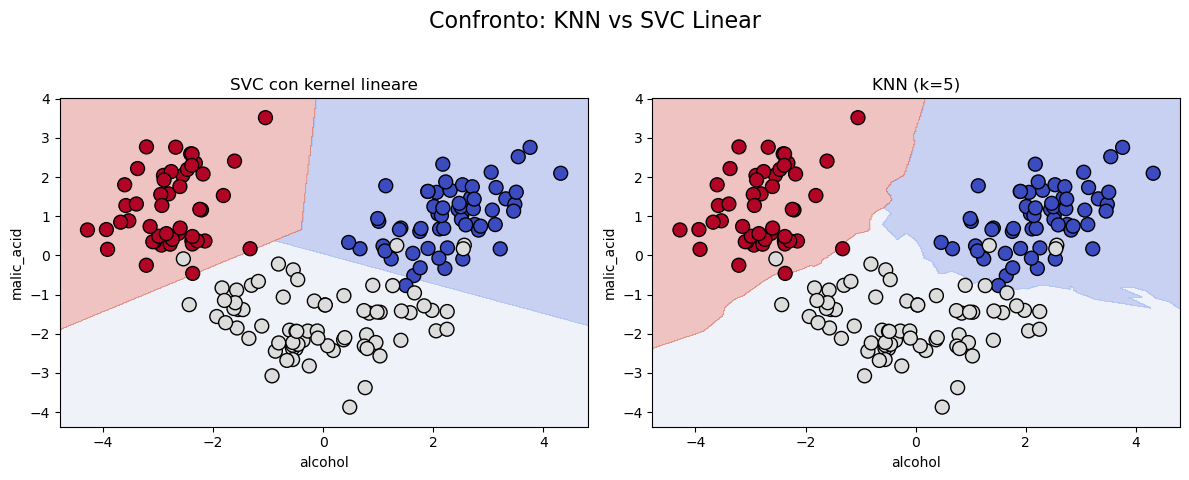

In [42]:
plt.figure(figsize=(12, 5))
plt.suptitle("Confronto: KNN vs SVC Linear", fontsize=16)

plt.subplot(1, 2, 1)
plt.contourf(xx, yy, Z_linear, alpha=0.3, cmap=plt.cm.coolwarm)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, edgecolors='k', marker='o', s=100, cmap=plt.cm.coolwarm)
plt.title("SVC con kernel lineare") 
plt.xlabel(data.feature_names[0])
plt.ylabel(data.feature_names[1])
plt.subplot(1, 2, 2)
plt.contourf(xx, yy, Z_rbf, alpha=0.3, cmap=plt.cm.coolwarm)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, edgecolors='k', marker='o', s=100, cmap=plt.cm.coolwarm)
plt.title("KNN (k=5)")
plt.xlabel(data.feature_names[0])
plt.ylabel(data.feature_names[1])
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()